In [37]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [38]:
X,y = make_classification(n_samples = 75,n_features = 2, n_redundant = 0,n_informative = 2,n_clusters_per_class = 1,random_state = 42)

In [39]:
Feature1 = 4 + (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min()) * 6
Feature2 = 40 + (X[:, 1] - X[:, 1].min()) / (X[:, 1].max() - X[:, 1].min()) * 60

In [40]:
df = pd.DataFrame({'Feature1': Feature1, 'Feature2': Feature2, 'Class': y})

df['Feature1'] = (df['Feature1'] - df['Feature1'].mean()) / df['Feature1'].std()
df['Feature2'] = (df['Feature2'] - df['Feature2'].mean()) / df['Feature2'].std()

In [41]:
df.head()

,Feature1,Feature2,Class
0,0.375501,-0.121659,1
1,0.263947,-1.814197,0
2,0.021507,-1.314660,0
3,-0.733024,0.144970,0
4,0.850220,1.130199,1


In [42]:
def initialize_parameters(layer_dims):
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters['W' + str(l)] = np.ones((layer_dims[l-1], layer_dims[l])) * 0.1
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

In [43]:
#utility Functions

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [44]:
def linear_forward(A_prev, W, b):
    Z = np.dot(W.T, A_prev) + b
    A = sigmoid(Z)
    return A

In [45]:
#L-layered feed forward

def L_layer_forward(X, parameters):
    A = X
    L = len(parameters) // 2
    for l in range(1, L+1):
        A_prev = A
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]
        A = linear_forward(A_prev, W, b)
    return A, A_prev #A = O11, A_prev = O12

In [46]:
def update_parameters(parameters, y, y_hat, A1, X, lr=0.5):
    W2_old = parameters['W2'].copy()

    # output layer gradient — sigmoid + BCE combine to this clean form
    dZ2 = y_hat - y                      # scalar

    dW2 = dZ2 * A1                       # shape (2,1)
    db2 = dZ2                            # scalar

    # hidden layer gradient
    dA1 = W2_old * dZ2                   # shape (2,1)
    dZ1 = dA1 * A1 * (1 - A1)            # sigmoid derivative, shape (2,1)

    dW1_col0 = dZ1[0][0] * X             # shape (2,1) — neuron 0's weights
    dW1_col1 = dZ1[1][0] * X             # shape (2,1) — neuron 1's weights

    # update — subtract lr * gradient (standard gradient descent)
    parameters['W2'][0][0] -= lr * dW2[0][0]
    parameters['W2'][1][0] -= lr * dW2[1][0]
    parameters['b2'][0][0] -= lr * db2

    parameters['W1'][0][0] -= lr * dW1_col0[0][0]
    parameters['W1'][1][0] -= lr * dW1_col0[1][0]
    parameters['b1'][0][0] -= lr * dZ1[0][0]

    parameters['W1'][0][1] -= lr * dW1_col1[0][0]
    parameters['W1'][1][1] -= lr * dW1_col1[1][0]
    parameters['b1'][1][0] -= lr * dZ1[1][0]

In [47]:
def bce_loss(y, y_hat):
    eps = 1e-9  # avoid log(0)
    return -(y * np.log(y_hat + eps) + (1-y) * np.log(1 - y_hat + eps))

parameters = initialize_parameters([2,2,1])
epochs = 100
lr = 0.3
for i in range(epochs):
    Loss = []

    for j in range(df.shape[0]):

        X = df[['Feature1','Feature2']].values[j].reshape(2,1)
        y = df[['Class']].values[j][0]

        y_hat, A1 = L_layer_forward(X, parameters)
        y_hat_val = y_hat[0][0]

        update_parameters(parameters, y, y_hat_val, A1, X, lr)

        Loss.append(bce_loss(y, y_hat_val))

    print('Epoch - ', i+1, 'Loss - ', np.mean(Loss))

Epoch -  1 Loss -  0.7101756269082922
Epoch -  2 Loss -  0.580719738644537
Epoch -  3 Loss -  0.3511900220911856
Epoch -  4 Loss -  0.23780359592361938
Epoch -  5 Loss -  0.194612173278752
Epoch -  6 Loss -  0.1743946108523514
Epoch -  7 Loss -  0.16337011186164926
Epoch -  8 Loss -  0.15672124603280274
Epoch -  9 Loss -  0.15241303254884825
Epoch -  10 Loss -  0.14946981109606594
Epoch -  11 Loss -  0.14737589623210132
Epoch -  12 Loss -  0.1458365071869907
Epoch -  13 Loss -  0.14467236884544435
Epoch -  14 Loss -  0.14376913680844114
Epoch -  15 Loss -  0.1430512275554472
Epoch -  16 Loss -  0.14246733544551082
Epoch -  17 Loss -  0.1419819355965889
Epoch -  18 Loss -  0.14157004987068197
Epoch -  19 Loss -  0.14121389538737522
Epoch -  20 Loss -  0.1409006739297426
Epoch -  21 Loss -  0.14062108132410123
Epoch -  22 Loss -  0.14036828573015722
Epoch -  23 Loss -  0.14013721867364964
Epoch -  24 Loss -  0.13992407838688953
Epoch -  25 Loss -  0.13972597920140958
Epoch -  26 Loss -  

In [48]:
loss_history = []

for i in range(epochs):

    Loss = []

    for j in range(df.shape[0]):

        X = df[['Feature1','Feature2']].values[j].reshape(2,1)
        y = df[['Class']].values[j][0]

        y_hat, A1 = L_layer_forward(X, parameters)
        y_hat = y_hat[0][0]

        update_parameters(parameters, y, y_hat, A1, X)

        sample_loss = -(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))
        Loss.append(sample_loss)

    epoch_loss = np.mean(Loss)
    loss_history.append(epoch_loss)

    print(f"Epoch {i+1}, Loss = {epoch_loss:.5f}")

Epoch 1, Loss = 0.14458
Epoch 2, Loss = 0.14085
Epoch 3, Loss = 0.14307
Epoch 4, Loss = 0.14074
Epoch 5, Loss = 0.14211
Epoch 6, Loss = 0.14072
Epoch 7, Loss = 0.14157
Epoch 8, Loss = 0.14071
Epoch 9, Loss = 0.14124
Epoch 10, Loss = 0.14069
Epoch 11, Loss = 0.14101
Epoch 12, Loss = 0.14065
Epoch 13, Loss = 0.14085
Epoch 14, Loss = 0.14060
Epoch 15, Loss = 0.14072
Epoch 16, Loss = 0.14054
Epoch 17, Loss = 0.14061
Epoch 18, Loss = 0.14048
Epoch 19, Loss = 0.14051
Epoch 20, Loss = 0.14041
Epoch 21, Loss = 0.14043
Epoch 22, Loss = 0.14034
Epoch 23, Loss = 0.14035
Epoch 24, Loss = 0.14028
Epoch 25, Loss = 0.14027
Epoch 26, Loss = 0.14021
Epoch 27, Loss = 0.14019
Epoch 28, Loss = 0.14014
Epoch 29, Loss = 0.14012
Epoch 30, Loss = 0.14007
Epoch 31, Loss = 0.14005
Epoch 32, Loss = 0.14000
Epoch 33, Loss = 0.13998
Epoch 34, Loss = 0.13993
Epoch 35, Loss = 0.13991
Epoch 36, Loss = 0.13987
Epoch 37, Loss = 0.13984
Epoch 38, Loss = 0.13980
Epoch 39, Loss = 0.13977
Epoch 40, Loss = 0.13974
Epoch 41,

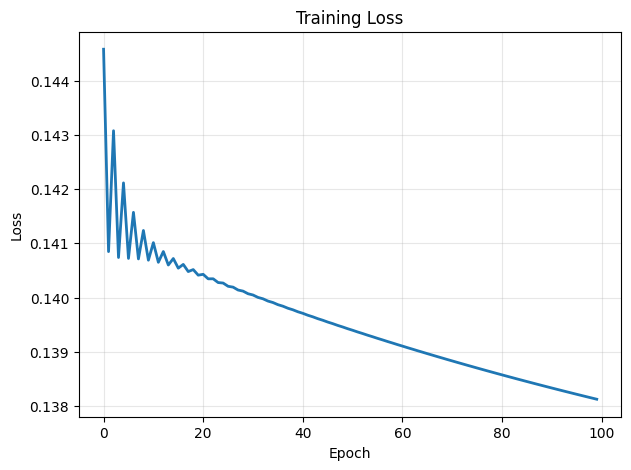

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(loss_history, linewidth=2)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)
plt.show()